In [1]:
%matplotlib inline

In [ ]:
# LABORATÓRIO 04 — ACO DO ZERO

import numpy as np
import random
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

In [3]:
# 1. Representação da rede utilizando uma matriz de custos
CUSTOS = np.array([
    [0, 2, 4, np.inf, np.inf, np.inf],
    [2, 0, 1, 5, np.inf, np.inf],
    [4, 1, 0, 2, 3, np.inf],
    [np.inf, 5, 2, 0, 1, 4],
    [np.inf, np.inf, 3, 1, 0, 2],
    [np.inf, np.inf, np.inf, 4, 2, 0]
])

ORIGEM = 0
DESTINO = 5

# Parâmetros mínimos
NUM_FORMIGAS = 20
NUM_ITERACOES = 50

ALPHA = 1.0
BETA = 2.0

TAXA_EVAPORACAO = 0.5
Q = 100

In [4]:
# 2. Criar uma matriz de feromônio
feromonio = np.ones_like(CUSTOS, dtype=float)
feromonio[CUSTOS == np.inf] = 0


def obter_vizinhos(no):
    vizinhos = []
    for proximo in range(len(CUSTOS)):
        if proximo != no and CUSTOS[no][proximo] != np.inf:
            vizinhos.append(proximo)
    return vizinhos


def calcular_atratividade(no_atual, proximo):
    fer = feromonio[no_atual][proximo]
    custo = CUSTOS[no_atual][proximo]
    return (fer ** ALPHA) * (1 / custo) ** BETA

In [ ]:
# 3 e 4. Criar formigas e fazer cada uma construir uma rota

In [6]:
# 5. impedindo que visite novamente um nó
def construir_rota():
    rota = [ORIGEM]
    atual = ORIGEM

    while atual != DESTINO:
        vizinhos = obter_vizinhos(atual)
        candidatos = [no for no in vizinhos if no not in rota]

        if not candidatos:
            return None

        atratividades = [calcular_atratividade(atual, proximo) for proximo in candidatos]
        soma = sum(atratividades)
        probabilidades = [valor / soma for valor in atratividades]

        proximo = random.choices(candidatos, weights=probabilidades, k=1)[0]

        rota.append(proximo)
        atual = proximo

    return rota

In [7]:
# 6. Calcular o custo de cada rota
def calcular_custo(rota):
    total = 0
    for i in range(len(rota) - 1):
        origem = rota[i]
        destino = rota[i + 1]
        total += CUSTOS[origem][destino]
    return total

In [8]:
# 7. Reforçar as melhores rotas com feromônio
def depositar_feromonio(rota, custo):
    deposito = Q / custo
    for i in range(len(rota) - 1):
        origem = rota[i]
        destino = rota[i + 1]
        feromonio[origem][destino] += deposito

In [9]:
# 8. Aplicar evaporação
def evaporar_feromonio():
    global feromonio
    feromonio *= (1 - TAXA_EVAPORACAO)
    feromonio[CUSTOS == np.inf] = 0

In [10]:
# 9. Repetir o processo por várias iterações
melhor_rota = None
melhor_custo = float("inf")
historico = []

for iteracao in range(NUM_ITERACOES):
    rotas = []

    for _ in range(NUM_FORMIGAS):
        rota = construir_rota()
        if rota is not None:
            custo = calcular_custo(rota)
            rotas.append((rota, custo))
            if custo < melhor_custo:
                melhor_custo = custo
                melhor_rota = rota.copy()

    evaporar_feromonio()

    for rota, custo in rotas:
        depositar_feromonio(rota, custo)

    historico.append(melhor_custo)

In [11]:
# 10 e 11. Informar a melhor rota e o custo
print("========== RESULTADO ==========")
print("Melhor rota encontrada:", melhor_rota)
print("Melhor custo:", melhor_custo)

========== RESULTADO ==========
Melhor rota encontrada: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


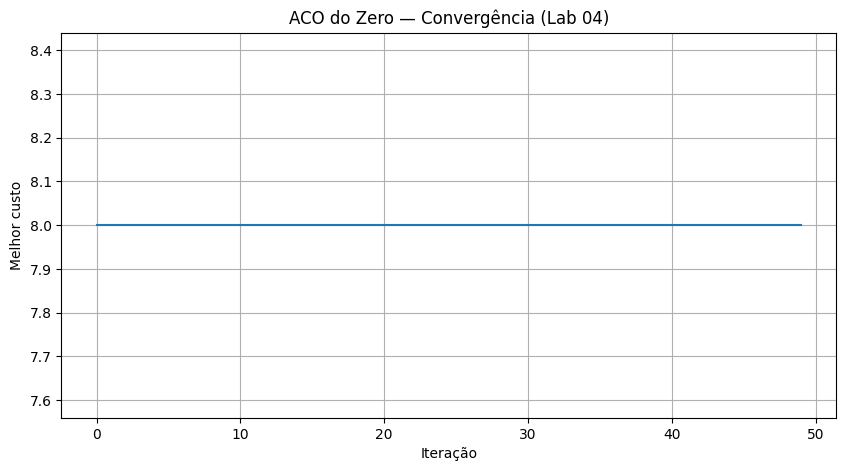


========== TESTE DE SENSIBILIDADE A PARÂMETROS ==========
Base               | NUM_FORMIGAS= 20 NUM_ITERACOES= 50 ALPHA=1.0 BETA=2.0 EVAP=0.5 -> Melhor rota=[0, 1, 2, 3, 4, 5] | Melhor custo=8.0


Mais formigas      | NUM_FORMIGAS= 50 NUM_ITERACOES= 50 ALPHA=1.0 BETA=2.0 EVAP=0.5 -> Melhor rota=[0, 1, 2, 3, 4, 5] | Melhor custo=8.0
Mais iterações     | NUM_FORMIGAS= 20 NUM_ITERACOES=150 ALPHA=1.0 BETA=2.0 EVAP=0.5 -> Melhor rota=[0, 1, 2, 3, 4, 5] | Melhor custo=8.0
ALPHA alto         | NUM_FORMIGAS= 20 NUM_ITERACOES= 50 ALPHA=5.0 BETA=2.0 EVAP=0.5 -> Melhor rota=[0, 1, 2, 3, 4, 5] | Melhor custo=8.0


BETA alto          | NUM_FORMIGAS= 20 NUM_ITERACOES= 50 ALPHA=1.0 BETA=5.0 EVAP=0.5 -> Melhor rota=[0, 1, 2, 3, 4, 5] | Melhor custo=8.0
Evaporação alta    | NUM_FORMIGAS= 20 NUM_ITERACOES= 50 ALPHA=1.0 BETA=2.0 EVAP=0.9 -> Melhor rota=[0, 1, 2, 3, 4, 5] | Melhor custo=8.0


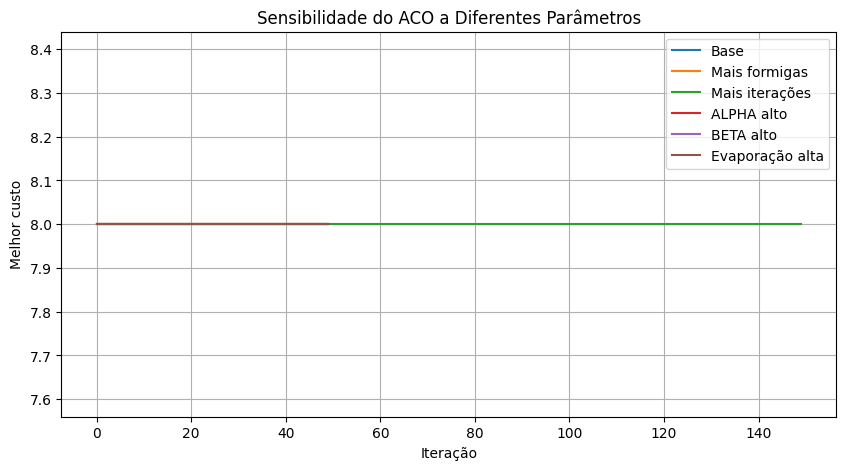

In [ ]:
# 12. Exibir gráfico da evolução do melhor custo
plt.figure(figsize=(10, 5))
plt.plot(historico)
plt.xlabel("Iteração")
plt.ylabel("Melhor custo")
plt.title("ACO do Zero — Convergência (Lab 04)")
plt.grid()
plt.show()

# ------------------------------------------------------------
# Testando a sensibilidade a diferentes parâmetros, como pedido
# ------------------------------------------------------------

def rodar_aco(num_formigas, num_iteracoes, alpha, beta, taxa_evaporacao, q=100, seed=42):
    random.seed(seed)
    np.random.seed(seed)
    fer = np.ones_like(CUSTOS, dtype=float)
    fer[CUSTOS == np.inf] = 0

    def atratividade_local(no_atual, proximo):
        return (fer[no_atual][proximo] ** alpha) * (1 / CUSTOS[no_atual][proximo]) ** beta

    def construir_rota_local():
        rota = [ORIGEM]
        atual = ORIGEM
        while atual != DESTINO:
            vizinhos = obter_vizinhos(atual)
            candidatos = [no for no in vizinhos if no not in rota]
            if not candidatos:
                return None
            atr = [atratividade_local(atual, p) for p in candidatos]
            soma = sum(atr)
            probs = [a / soma for a in atr]
            proximo = random.choices(candidatos, weights=probs, k=1)[0]
            rota.append(proximo)
            atual = proximo
        return rota

    melhor_r, melhor_c, hist = None, float("inf"), []
    for _ in range(num_iteracoes):
        rotas = []
        for _ in range(num_formigas):
            rota = construir_rota_local()
            if rota is not None:
                custo = calcular_custo(rota)
                rotas.append((rota, custo))
                if custo < melhor_c:
                    melhor_c = custo
                    melhor_r = rota.copy()
        fer *= (1 - taxa_evaporacao)
        fer[CUSTOS == np.inf] = 0
        for rota, custo in rotas:
            deposito = q / custo
            for i in range(len(rota) - 1):
                fer[rota[i]][rota[i + 1]] += deposito
        hist.append(melhor_c)
    return melhor_r, melhor_c, hist


configuracoes = [
    ("Base",              20, 50, 1.0, 2.0, 0.5),
    ("Mais formigas",     50, 50, 1.0, 2.0, 0.5),
    ("Mais iterações",    20, 150, 1.0, 2.0, 0.5),
    ("ALPHA alto",        20, 50, 5.0, 2.0, 0.5),
    ("BETA alto",         20, 50, 1.0, 5.0, 0.5),
    ("Evaporação alta",   20, 50, 1.0, 2.0, 0.9),
]

print("\n========== TESTE DE SENSIBILIDADE A PARÂMETROS ==========")
resultados_sensibilidade = {}
for nome, nf, ni, a, b, te in configuracoes:
    mr, mc, hist = rodar_aco(nf, ni, a, b, te)
    resultados_sensibilidade[nome] = hist
    print(f"{nome:18s} | NUM_FORMIGAS={nf:3d} NUM_ITERACOES={ni:3d} "
          f"ALPHA={a} BETA={b} EVAP={te} -> Melhor rota={mr} | Melhor custo={mc}")

plt.figure(figsize=(10, 5))
for nome, hist in resultados_sensibilidade.items():
    plt.plot(hist, label=nome)
plt.xlabel("Iteração")
plt.ylabel("Melhor custo")
plt.title("Sensibilidade do ACO a Diferentes Parâmetros")
plt.legend()
plt.grid()
plt.show()